In this Jupyterbook, we will see a way to decode the neuronal activity.
We will use real data from single neurons recording from the Primary somatosensory cortex during tactile stimulations (stimulation of finger tip 2, 3, 4 or 5)

To Do before the next session, answer the following questions

- what is decoding ? 
- why using an artificial neural network to decode the information contained in single unit data ? 
- why should we use a multi-layer network and not a simple perceptron ? 




In [75]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import random
import warnings
import sys

import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
plt.style.use('dark_background')





neuron1 = np.zeros(1000) 
neuron1[500:] = 1 

neuron2 = np.zeros(1000)
neuron2[0:500] = 1

neuronpop=np.hstack((neuron1, neuron2))
Neuronpop=np.reshape(neuronpop, (2, 1000)).T


stim=np.zeros(1000)
stim[0:500] = 0
stim[500:] = 1
stim_df = pd.DataFrame(stim, columns=['stimulus'])

Neuronpop_df = pd.DataFrame(Neuronpop, columns=['neuron1', 'neuron2'])
Neuronpop_df

,neuron1,neuron2
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
995,1.0,0.0
996,1.0,0.0
997,1.0,0.0
998,1.0,0.0


Accuracy: 1.00


Text(0.5, 1.0, 'Perceptron Confusion Matrix')

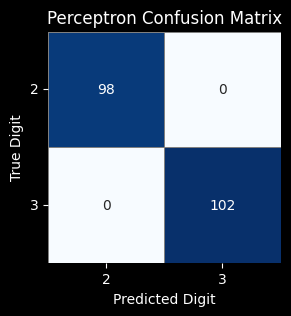

In [92]:
## perceptron for N neurons and 2 classes
### using sklearn Perceptron

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

X=np.reshape(neuron2.T, (-1, 1)) #Neuronpop

y=stim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create and train the Perceptron model
perceptron = Perceptron()

perceptron.fit(X_train, y_train)

# Make predictions on the test set
y_pred = perceptron.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,linewidths=0.5, linecolor='gray')
ax.set_xticklabels(['2','3'])
ax.set_yticklabels(['2','3'], rotation=0)
ax.set_xlabel('Predicted Digit')
ax.set_ylabel('True Digit')
ax.set_title('Perceptron Confusion Matrix')


